In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

np.random.seed(42)



In [31]:

import yfinance as yf

start_date = "2015-01-01"
end_date   = "2024-12-31"

df_raw = yf.download("MSFT", start=start_date, end=end_date, auto_adjust=False, progress=False)
df_raw = df_raw.reset_index()

df_raw.head(), df_raw.shape

(Price        Date  Adj Close      Close       High        Low       Open  \
 Ticker                  MSFT       MSFT       MSFT       MSFT       MSFT   
 0      2015-01-02  39.858452  46.759998  47.419998  46.540001  46.660000   
 1      2015-01-05  39.491928  46.330002  46.730000  46.250000  46.369999   
 2      2015-01-06  38.912266  45.650002  46.750000  45.540001  46.380001   
 3      2015-01-07  39.406685  46.230000  46.459999  45.490002  45.980000   
 4      2015-01-08  40.565952  47.590000  47.750000  46.720001  46.750000   
 
 Price     Volume  
 Ticker      MSFT  
 0       27913900  
 1       39673900  
 2       36447900  
 3       29114100  
 4       29645200  ,
 (2515, 7))

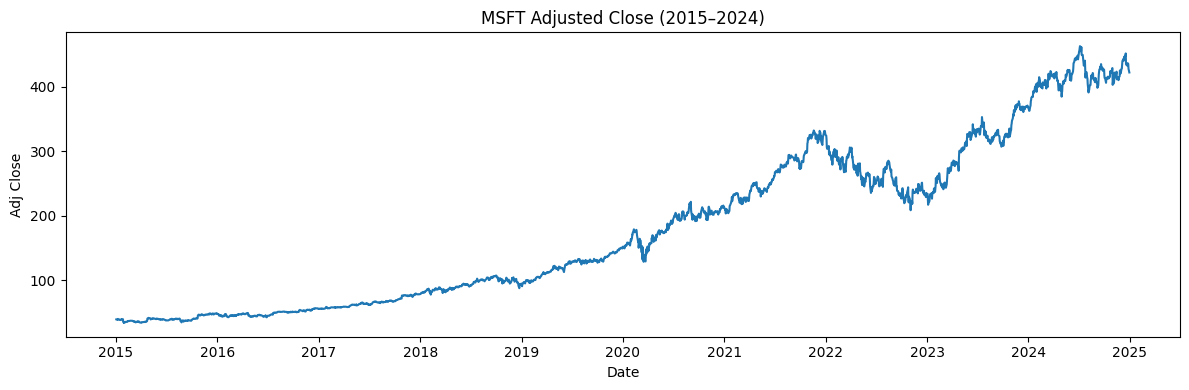

In [32]:
plt.figure(figsize=(12,4))
plt.plot(df_raw["Date"], df_raw["Adj Close"])
plt.title("MSFT Adjusted Close (2015–2024)")
plt.xlabel("Date"); plt.ylabel("Adj Close")
plt.tight_layout()
plt.show()



In [33]:


print(df.columns)


Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'log_px',
       'ret1', 'ret5', 'ret20', 'ma_5', 'ema_5', 'ma_20', 'ema_20', 'ma_60',
       'ema_60', 'px_ma5', 'px_ma20', 'px_ma60', 'roc_5', 'roc_20', 'vol_10',
       'vol_20', 'vol_60', 'mom_10', 'mom_20', 'vol_z20', 'vroc_5',
       'ret1_lag1', 'ret1_lag2', 'ret1_lag3', 'ret1_lag5', 'ratio_fwd',
       'ret_fwd'],
      dtype='object')


In [34]:
df = df_raw.copy().sort_values("Date").reset_index(drop=True)
# ---- FIX MULTIINDEX FROM YFINANCE ----
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [
        col[0] if col[1] == "" else col[0]
        for col in df.columns
    ]
# Core series
df["log_px"] = np.log(df["Adj Close"].astype(float))
df["ret1"]   = df["log_px"].diff()                 # daily log return
df["ret5"]   = df["log_px"].diff(5)
df["ret20"]  = df["log_px"].diff(20)

# Moving averages
for w in [5, 20, 60]:
    df[f"ma_{w}"]  = df["Adj Close"].rolling(w).mean()
    df[f"ema_{w}"] = df["Adj Close"].ewm(span=w, adjust=False).mean()

# Price-to-MA ratios (more stationary than raw price)
df["px_ma5"]  = df["Adj Close"] / df["ma_5"]  - 1.0
df["px_ma20"] = df["Adj Close"] / df["ma_20"] - 1.0
df["px_ma60"] = df["Adj Close"] / df["ma_60"] - 1.0

# Rate of Change (ROC)
df["roc_5"]  = df["Adj Close"].pct_change(5)
df["roc_20"] = df["Adj Close"].pct_change(20)

# Rolling volatility
df["vol_10"] = df["ret1"].rolling(10).std()
df["vol_20"] = df["ret1"].rolling(20).std()
df["vol_60"] = df["ret1"].rolling(60).std()

# Momentum indicators
df["mom_10"] = df["Adj Close"] / df["Adj Close"].shift(10) - 1.0
df["mom_20"] = df["Adj Close"] / df["Adj Close"].shift(20) - 1.0

# Volume-based features
df["vol_z20"] = (df["Volume"] - df["Volume"].rolling(20).mean()) / df["Volume"].rolling(20).std()
df["vroc_5"]  = df["Volume"].pct_change(5)

# Lagged returns
for lag in [1, 2, 3, 5]:
    df[f"ret1_lag{lag}"] = df["ret1"].shift(lag)

# Targets required later:
# next-day price ratio (assignment asks ML predicts future price ratio) :contentReference[oaicite:4]{index=4}
df["ratio_fwd"] = df["Adj Close"].shift(-1) / df["Adj Close"]
df["ret_fwd"]   = np.log(df["ratio_fwd"])  # next-day log return

# Drop NaNs created by rolling/shift
df_feat = df.dropna().reset_index(drop=True)

df_feat.shape


(2454, 35)

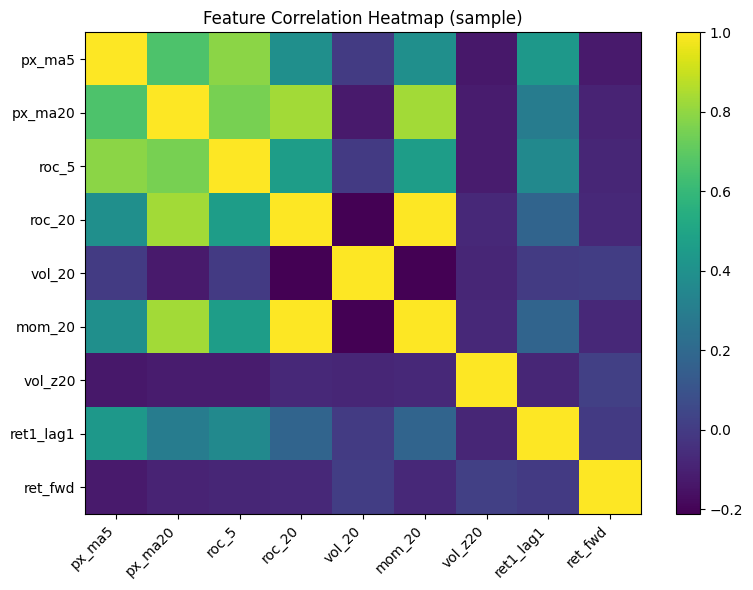

In [35]:
feature_cols_preview = ["px_ma5","px_ma20","roc_5","roc_20","vol_20","mom_20","vol_z20","ret1_lag1"]
corr = df_feat[feature_cols_preview + ["ret_fwd"]].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Feature Correlation Heatmap (sample)")
plt.colorbar()
plt.tight_layout()
plt.show()


In [36]:
def kalman_tvr(y, X, q=1e-5, r=1e-3, init_cov=1.0):
    """
    Time-Varying Regression via Kalman Filter
    State: beta_t (k-dim)
    Observation: y_t = X_t beta_t + eps, eps ~ N(0, r)
    Transition:  beta_t = beta_{t-1} + w, w ~ N(0, q I)

    Returns:
      beta_filt: (T, k) filtered betas
      y_pred:    (T,)  one-step-ahead prediction using beta_{t-1}
    """
    T, k = X.shape
    beta = np.zeros(k)
    P = np.eye(k) * init_cov
    Q = np.eye(k) * q
    R = r

    beta_filt = np.zeros((T, k))
    y_pred = np.zeros(T)

    for t in range(T):
        x = X[t]

        # Predict
        beta_pred = beta
        P_pred = P + Q

        # Predict observation
        yhat = x @ beta_pred
        y_pred[t] = yhat

        # Update
        S = x @ P_pred @ x.T + R
        K = (P_pred @ x.T) / S
        innov = y[t] - yhat

        beta = beta_pred + K * innov
        P = (np.eye(k) - np.outer(K, x)) @ P_pred

        beta_filt[t] = beta

    return beta_filt, y_pred


In [37]:
feature_cols = [
    "px_ma5","px_ma20","px_ma60",
    "roc_5","roc_20",
    "vol_10","vol_20",
    "mom_10","mom_20",
    "vol_z20","vroc_5",
    "ret1_lag1","ret1_lag2","ret1_lag3","ret1_lag5"
]

y = df_feat["ret_fwd"].values
X = df_feat[feature_cols].values

# Add intercept term so Kalman learns a drifting alpha
X_kf = np.column_stack([np.ones(len(df_feat)), X])
kf_cols = ["beta_intercept"] + [f"beta_{c}" for c in feature_cols]

beta_filt, y_pred = kalman_tvr(y, X_kf, q=1e-5, r=1e-3, init_cov=1.0)

beta_df = pd.DataFrame(beta_filt, columns=kf_cols)
df_k = pd.concat([df_feat.reset_index(drop=True), beta_df], axis=1)


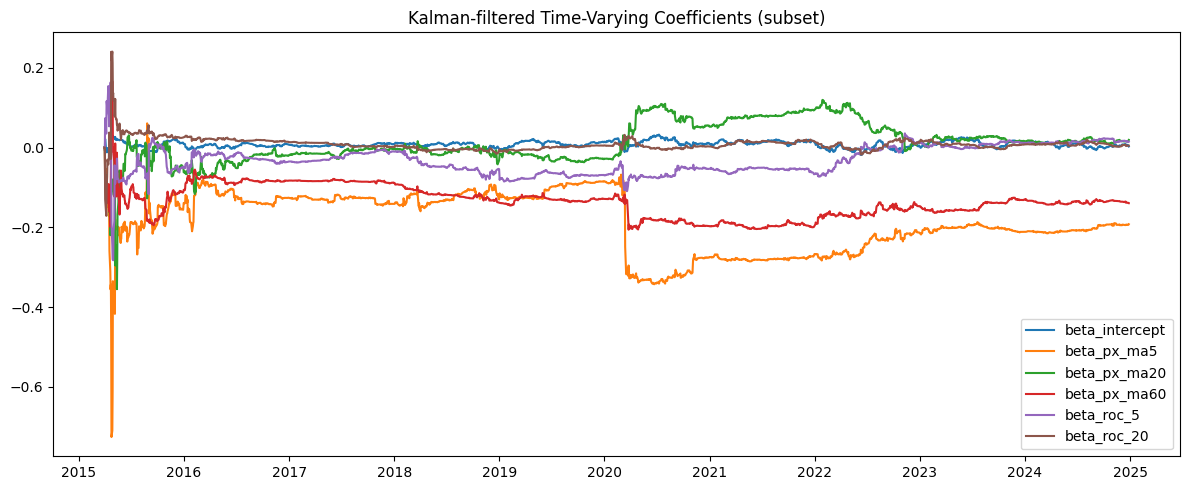

In [38]:
plt.figure(figsize=(12,5))
for c in kf_cols[:6]:   # plot first few so it’s readable
    plt.plot(df_k["Date"], df_k[c], label=c)
plt.title("Kalman-filtered Time-Varying Coefficients (subset)")
plt.legend()
plt.tight_layout()
plt.show()


In [39]:
X_cols = feature_cols + kf_cols
target = "ratio_fwd"

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=2.0))
])

pred_ratio = pd.Series(index=df_k.index, dtype=float)

train_years = 3

for i, dt in enumerate(df_k["Date"]):
    # train on past 3 years only (rolling)
    start_train = dt - pd.DateOffset(years=train_years)
    mask_train = (df_k["Date"] < dt) & (df_k["Date"] >= start_train)

    if mask_train.sum() < 252:   # need at least ~1 year
        continue

    X_train = df_k.loc[mask_train, X_cols].values
    y_train = df_k.loc[mask_train, target].values

    X_test = df_k.loc[[i], X_cols].values

    model.fit(X_train, y_train)
    pred_ratio.iloc[i] = model.predict(X_test)[0]

df_k["pred_ratio"] = pred_ratio
df_k = df_k.dropna(subset=["pred_ratio"]).reset_index(drop=True)


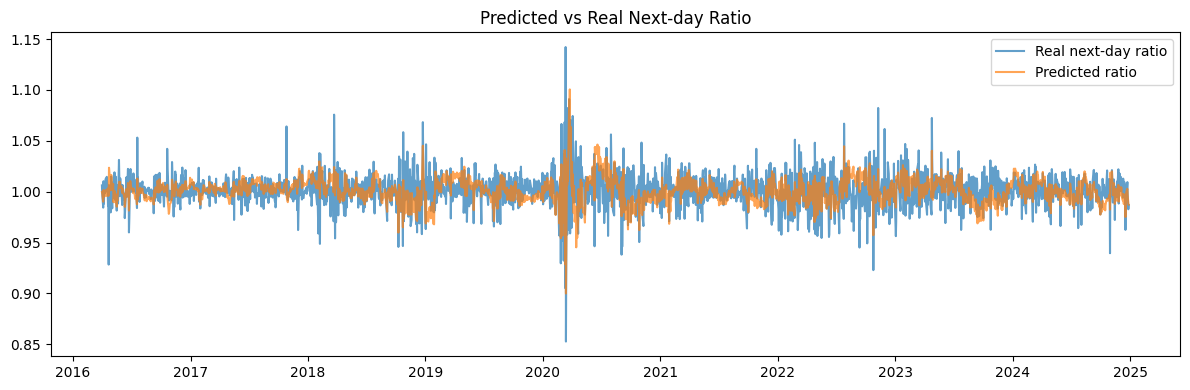

In [40]:
plt.figure(figsize=(12,4))
plt.plot(df_k["Date"], df_k["ratio_fwd"], label="Real next-day ratio", alpha=0.7)
plt.plot(df_k["Date"], df_k["pred_ratio"], label="Predicted ratio", alpha=0.7)
plt.title("Predicted vs Real Next-day Ratio")
plt.legend()
plt.tight_layout()
plt.show()


In [46]:
df_k["pred_ret"] = df_k["pred_ratio"] - 1.0
df_k["real_ret"] = df_k["ratio_fwd"] - 1.0

# rolling sigma of past prediction errors (shifted to avoid using today's error)
df_k["pred_err"] = (df_k["real_ret"] - df_k["pred_ret"]).shift(1)
df_k["sigma_err"] = df_k["pred_err"].rolling(60).std()

k = 0.75  # threshold strength
df_k["thr"] = k * df_k["sigma_err"]
df_k["thr"] = df_k["thr"].fillna(df_k["thr"].median())

enter_k = 0.90
exit_k  = 0.30

df_k["thr_enter"] = enter_k * df_k["sigma_err"]
df_k["thr_exit"]  = exit_k  * df_k["sigma_err"]

pos = []
current_pos = 0.0

for i in range(len(df_k)):
    pr = df_k.loc[i, "pred_ret"]
    te = df_k.loc[i, "thr_enter"]
    tx = df_k.loc[i, "thr_exit"]

    if current_pos == 0.0:
        if pr > te:          # enter only on strong signal
            current_pos = 1.0
    else:
        if pr < tx:          # exit only when signal weakens a lot
            current_pos = 0.0

    pos.append(current_pos)

df_k["pos_t"] = pos
df_k["pos_exec"] = df_k["pos_t"].shift(1).fillna(0.0)



In [47]:
max_pos = 1.0
stop_loss = 0.07       # 7% drawdown in a trade triggers exit
tx_cost_bps = 5.0      # transaction cost per turnover (hint mentions tx costs) :contentReference[oaicite:13]{index=13}

pos = []
current_pos = 0.0

for i in range(len(df_k)):
    sig = df_k.loc[i, "signal"]

    if current_pos == 0.0 and sig == 1:
        current_pos = 1.0   # enter long

    elif current_pos == 1.0 and sig == 0:
        current_pos = 0.0   # exit only when signal disappears

    pos.append(current_pos)

df_k["pos_t"] = pos
df_k["pos_exec"] = df_k["pos_t"].shift(1).fillna(0.0)



In [48]:
# transaction costs based on turnover
df_k["turnover"] = (df_k["pos_exec"] - df_k["pos_exec"].shift(1).fillna(0.0)).abs()
df_k["tx_cost"] = df_k["turnover"] * (tx_cost_bps / 10000.0)

# daily strategy return
df_k["strat_ret"] = df_k["pos_exec"] * df_k["real_ret"] - df_k["tx_cost"]
df_k["bh_ret"] = df_k["real_ret"]  # buy & hold benchmark

# equity curves
df_k["equity"] = (1.0 + df_k["strat_ret"]).cumprod()
df_k["bh_equity"] = (1.0 + df_k["bh_ret"]).cumprod()

df_k[["Date","pos_exec","strat_ret","equity"]].head()


,Date,pos_exec,strat_ret,equity
0,2016-03-31,0.0,0.0,1.0
1,2016-04-01,0.0,-0.0,1.0
2,2016-04-04,0.0,-0.0,1.0
3,2016-04-05,0.0,0.0,1.0
4,2016-04-06,0.0,-0.0,1.0


In [49]:
def max_drawdown(equity):
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return dd.min()

def sharpe(daily_ret):
    r = daily_ret.dropna()
    return np.sqrt(252) * r.mean() / r.std(ddof=1)

# Trade-level win/loss (approx: close trade when position goes 0 or flips sign)
trade_pnls = []
in_trade = False
trade_pnl = 1.0
trade_pos = 0.0

for i in range(len(df_k)):
    p = df_k.loc[i, "pos_exec"]
    r = df_k.loc[i, "real_ret"]

    if (not in_trade) and p != 0:
        in_trade = True
        trade_pos = p
        trade_pnl = 1.0

    if in_trade:
        trade_pnl *= (1.0 + trade_pos * r)

        # close trade if position ends or flips
        next_p = df_k.loc[i+1, "pos_exec"] if i < len(df_k)-1 else 0.0
        if next_p == 0.0 or np.sign(next_p) != np.sign(trade_pos):
            trade_pnls.append(trade_pnl - 1.0)
            in_trade = False

trade_pnls = pd.Series(trade_pnls)

metrics = {
    "Strategy Cumulative Return": df_k["equity"].iloc[-1] - 1.0,
    "BuyHold Cumulative Return": df_k["bh_equity"].iloc[-1] - 1.0,
    "Strategy Sharpe": sharpe(df_k["strat_ret"]),
    "Max Drawdown": max_drawdown(df_k["equity"]),
    "Num Trades": len(trade_pnls),
    "Win/Loss Ratio": (trade_pnls > 0).sum() / max(1, (trade_pnls < 0).sum()),
    "Avg Trade Return": trade_pnls.mean() if len(trade_pnls) else 0.0,
}

metrics


{'Strategy Cumulative Return': np.float64(-0.05229477786040293),
 'BuyHold Cumulative Return': np.float64(7.658248944651977),
 'Strategy Sharpe': np.float64(0.022524706398228046),
 'Max Drawdown': np.float64(-0.36439955799520163),
 'Num Trades': 230,
 'Win/Loss Ratio': np.float64(0.9166666666666666),
 'Avg Trade Return': np.float64(0.0011646152164576352)}

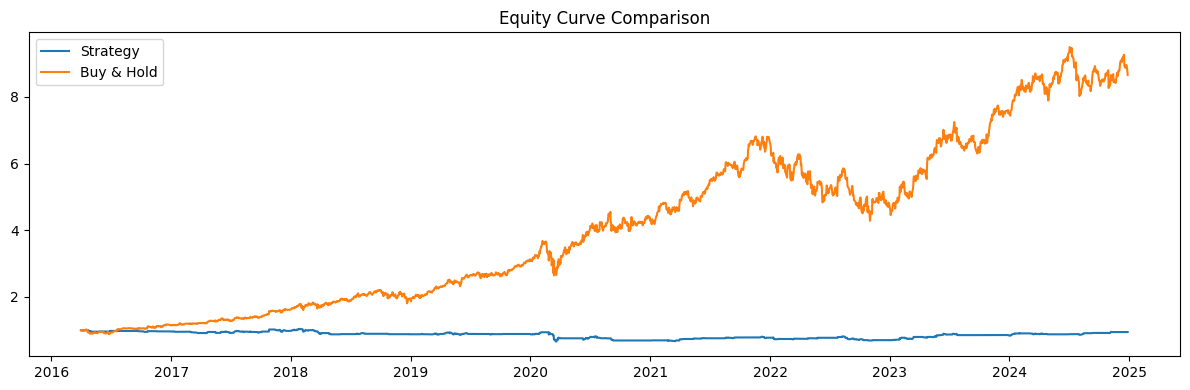

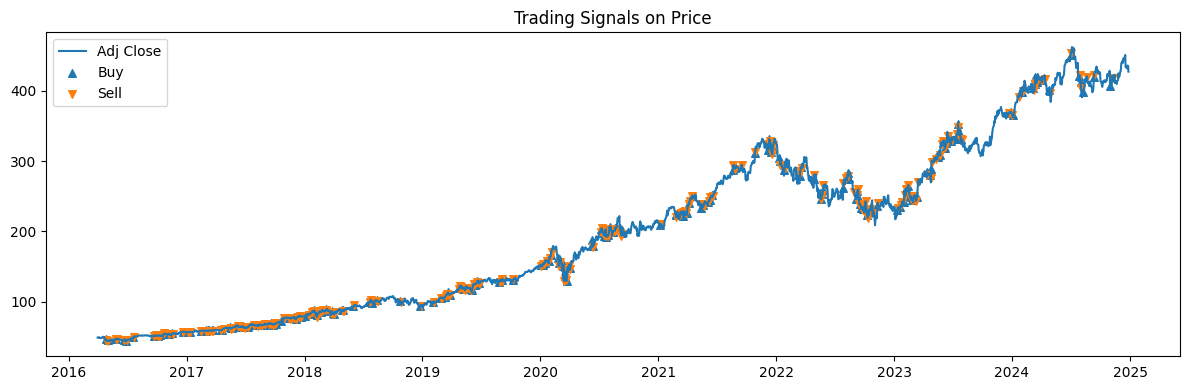

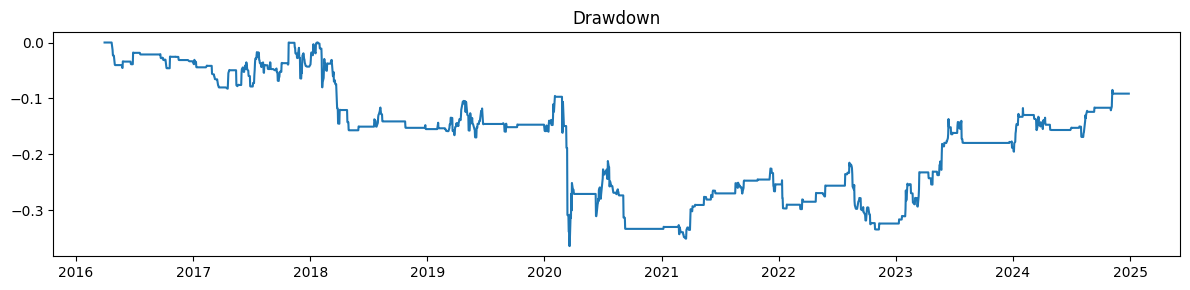

In [50]:
# 1) Equity curve vs buy & hold
plt.figure(figsize=(12,4))
plt.plot(df_k["Date"], df_k["equity"], label="Strategy")
plt.plot(df_k["Date"], df_k["bh_equity"], label="Buy & Hold")
plt.title("Equity Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Price with buy/sell markers (position changes)
plt.figure(figsize=(12,4))
plt.plot(df_k["Date"], df_k["Adj Close"], label="Adj Close")

buy = df_k["pos_exec"].diff().fillna(0) > 0
sell = df_k["pos_exec"].diff().fillna(0) < 0

plt.scatter(df_k.loc[buy, "Date"], df_k.loc[buy, "Adj Close"], marker="^", s=30, label="Buy")
plt.scatter(df_k.loc[sell, "Date"], df_k.loc[sell, "Adj Close"], marker="v", s=30, label="Sell")

plt.title("Trading Signals on Price")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Drawdown plot (extra robustness)
peak = df_k["equity"].cummax()
dd = df_k["equity"]/peak - 1.0

plt.figure(figsize=(12,3))
plt.plot(df_k["Date"], dd)
plt.title("Drawdown")
plt.tight_layout()
plt.show()
